# Population Dynamics and Climate in Soran, Iraq — Clean Reanalysis

**Revision 4 · rebuilt on the official annual population series**

This notebook replaces `Soran_Population_Forecast_Reanalysis_revised.ipynb`. It is
self-contained: it reads only the two raw workbooks in `data/`, applies a documented
cleaning protocol, and writes every table and figure used in the manuscript to
`outputs/`. Running it top to bottom on a clean kernel reproduces the entire
quantitative content of the paper.

## What changed relative to the previous notebook

| | Previous notebook (R3) | This notebook |
|---|---|---|
| Population input | `2.xlsx`, monthly, 2015–2024, 104,000 → 201,403 | `population_annual.xlsx`, annual, **2010–2024**, 56,761 → 91,589 |
| Provenance | undocumented; values are a within-year linear interpolation | Statistics Directorate, Soran Independent Administration (2010–2023) + 2024 census round |
| Effective annual N | 10 | **15** |
| Rolling-origin folds | 5 | **7** |
| Climate cleaning | blank-cell interpolation only | 6 documented QA rules, every corrected cell logged |
| Structural break | not considered | 2024 rebasing identified, tested, and modelled explicitly |
| Headline forecast | polynomial / MLP / ARIMAX point forecasts | growth-rate projection anchored on the 2024 census level, with scenario bands |

## Three findings that change how the results must be written up

1. **The 2010–2023 population values are administrative *estimates*, not counts.**
   They follow an almost exactly smooth declining-growth rule (year-on-year growth
   falls monotonically from 2.70% to 1.96%). Any model fitted to them scores a
   near-perfect out-of-sample MAPE — §3 shows a naive drift forecast reaching
   **0.09% MAPE**. That number measures the smoothness of the input series, not
   forecasting skill, and must not be reported as accuracy.
2. **2024 is a level shift, not a data point on the same curve.** The 2023 → 2024
   step is +18.4% against a 2.0%/yr trend — a 178-residual-SD event on the pre-2024 growth
   distribution. It reflects the 2024 census round replacing an estimate, so it is
   modelled as a permanent level shift rather than as growth (§2, §5).
3. **The climate–demography correlation cannot be tested on these data.** Because
   the pre-2024 population values are generated by a smooth rule, their year-on-year
   variation carries no independent demographic signal to correlate against climate.
   §4 reports the correlation for completeness and states this limitation explicitly.

## Reproducibility

Fixed seed (`SEED = 42`); no network access; no manual steps. `outputs/run_manifest.json`
records the seed, package versions and input-file checksums for the run that produced
the archived results.

## 0. Setup

In [1]:
import os, sys, json, random, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.simplefilter("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- paths -----------------------------------------------------------------
NB_DIR = Path.cwd()
DATA_DIR = NB_DIR / "data"
if not DATA_DIR.exists():                      # fallback if run from elsewhere
    DATA_DIR = Path(__file__).resolve().parent / "data" if "__file__" in globals() else DATA_DIR
OUT = NB_DIR / "outputs"
TAB, FIG = OUT / "tables", OUT / "figures"
for d in (TAB, FIG):
    d.mkdir(parents=True, exist_ok=True)

POP_XLSX     = DATA_DIR / "population_annual.xlsx"          # official annual series
CLIMATE_XLSX = DATA_DIR / "climate_monthly_raw.xlsx"        # station log, 2015-2024
LEGACY_XLSX  = DATA_DIR / "legacy_population_monthly.xlsx"  # series used in R1-R3

# --- constants used throughout ---------------------------------------------
AREA_KM2       = 2135.0                 # Soran administrative area (see 1.1)
CENSUS_YEAR    = 2024                   # year of the census-based rebasing
FORECAST_YEARS = list(range(2025, 2031))
MIN_TRAIN      = 8                      # smallest training window for rolling-origin CV

# --- figure style: recessive axes, thin marks, fixed categorical order ------
PAL = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a",
       "yellow": "#eda100", "violet": "#4a3aa7", "red": "#e34948",
       "ink": "#0b0b0b", "ink2": "#52514e", "grid": "#dcdcd8"}
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.edgecolor": PAL["ink2"], "axes.linewidth": 0.8,
    "axes.labelcolor": PAL["ink"], "text.color": PAL["ink"],
    "xtick.color": PAL["ink2"], "ytick.color": PAL["ink2"],
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": PAL["grid"], "grid.linewidth": 0.6,
    "legend.frameon": False, "figure.facecolor": "white",
})

print("Python", sys.version.split()[0])
for m in (np, pd, mpl):
    print(f"  {m.__name__:<12} {m.__version__}")
print("data dir:", DATA_DIR)

Python 3.11.15
  numpy        2.4.4
  pandas       3.0.2
  matplotlib   3.10.9
data dir: /root/gh_update/data


## 1. Data

### 1.1 Annual population, 2010–2024

`population_annual.xlsx` holds one value per year for the Soran district centre
(*Naewendî Soran / Soran markaz*). Source: Statistics Directorate of the Soran
Independent Administration, table *"Estimated population of the Soran Independent
Administration area, 2010–2023"*, extended with the 2024 census round.

Two properties of this series drive everything downstream and must be stated in the
Data section of the manuscript:

* **2010–2023 are official *estimates*.** The source note states that population
  growth was *estimated as a percentage rate* applied to the 2009–2010 building-and-
  population enumeration. They are therefore a smooth interpolation between two
  enumerations, not fifteen independent measurements.
* **2024 comes from a different instrument** — the 2024 population and housing
  census round, which put the whole Soran district at 179,596 persons. The district
  centre value of 91,589 is on a rebased footing and is not comparable year-on-year
  with 2023.

Population density is derived as population / 2,135 km², the administrative area
implied by the density column of the legacy workbook (201,403 / 94.334 = 2,135.0 km²);
it is a deterministic rescaling of population and carries no independent information.

In [2]:
pop = (pd.read_excel(POP_XLSX)
         .rename(columns={"years": "year", "population.soran": "population"})
         [["year", "population"]]
         .dropna()
         .astype({"year": int, "population": float})
         .sort_values("year")
         .reset_index(drop=True))

pop["density_per_km2"] = pop.population / AREA_KM2
pop["growth_rate_pct"] = pop.population.pct_change() * 100
pop["source"] = np.where(pop.year >= CENSUS_YEAR,
                         "2024 census round", "administrative estimate")

pop.to_csv(TAB / "population_annual_clean.csv", index=False)
YEARS = pop.year.tolist()
POPV  = pop.population.values
pop.round(3)

,year,population,density_per_km2,growth_rate_pct,source
0,2010,56761.0,26.586,NaN,administrative estimate
1,2011,58294.0,27.304,2.701,administrative estimate
2,2012,59867.0,28.041,2.698,administrative estimate
3,2013,61424.0,28.770,2.601,administrative estimate
4,2014,63021.0,29.518,2.600,administrative estimate
5,2015,64660.0,30.286,2.601,administrative estimate
6,2016,66341.0,31.073,2.600,administrative estimate
7,2017,67999.0,31.850,2.499,administrative estimate
8,2018,69631.0,32.614,2.400,administrative estimate
9,2019,71233.0,33.364,2.301,administrative estimate


### 1.2 Relationship to the series used in the earlier submission

The version of the manuscript sent to reviewers used `population.soran` from
`2.xlsx`: a *monthly* series running 104,000 (Jan 2015) to 201,403 (2024). That
series is a within-year linear interpolation (the first three 2015 values are
104,000 / 104,333 / 104,667 — exact steps of 333⅓), and its level is roughly double
the official district-centre figures for the same years. The most likely explanation
is that it refers to the whole Soran district rather than the district centre, but
its provenance is not documented in the manuscript.

The table below is the reconciliation reviewers will ask for. It should be
reproduced in the response letter; the two series are **not** interchangeable and
every number in the paper changes with the switch.

In [3]:
legacy = pd.read_excel(LEGACY_XLSX)
legacy_annual = (legacy.groupby("years")["population.soran"].max()
                       .rename("legacy_population").reset_index()
                       .rename(columns={"years": "year"}))

comparison = (pop[["year", "population", "source"]]
              .rename(columns={"population": "official_population"})
              .merge(legacy_annual, on="year", how="left"))
comparison["ratio_legacy_to_official"] = (comparison.legacy_population
                                          / comparison.official_population)
comparison.to_csv(TAB / "population_series_comparison.csv", index=False)
comparison.round(3)

,year,official_population,source,legacy_population,ratio_legacy_to_official
0,2010,56761.0,administrative estimate,NaN,NaN
1,2011,58294.0,administrative estimate,NaN,NaN
2,2012,59867.0,administrative estimate,NaN,NaN
3,2013,61424.0,administrative estimate,NaN,NaN
4,2014,63021.0,administrative estimate,NaN,NaN
5,2015,64660.0,administrative estimate,107333.0,1.660
6,2016,66341.0,administrative estimate,111667.0,1.683
7,2017,67999.0,administrative estimate,115667.0,1.701
8,2018,69631.0,administrative estimate,119667.0,1.719
9,2019,71233.0,administrative estimate,123667.0,1.736


### 1.3 Monthly meteorological record, 2015–2024

`climate_monthly_raw.xlsx` is the Soran agro-meteorological station log exported
from SPSS: 120 station-months, 2015–2024. Two structural quirks are handled before
anything else:

* **December mislabelling** — each year's December row is written at the top of the
  following year's block, a data-entry convention carried through every export of
  this log. `fix_december_labels()` reassigns it.
* **Month names** are inconsistent text (`Aprl`, `June`, `July`); `parse_month()`
  normalises them to 1–12.

In [4]:
MONTH_MAP = {m: i for i, m in enumerate(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], start=1)}
MONTH_ALIAS = {"aprl": 4, "june": 6, "july": 7, "sept": 9}

def parse_month(m):
    """Normalise the station log's inconsistent month labels to 1-12."""
    if isinstance(m, (int, np.integer)):
        return int(m)
    s = str(m).strip().lower()
    return MONTH_ALIAS.get(s, MONTH_MAP[s[:3].title()])

def fix_december_labels(df, year_col="years", month_col="month"):
    """Each year's December row is written as the first row of the NEXT year's
    block in this log. Reassign it to the year it belongs to."""
    years, months = df[year_col].tolist(), df[month_col].tolist()
    fixed = years.copy()
    for i in range(len(df) - 1):
        if months[i] == 12 and months[i + 1] == 1 and years[i + 1] == years[i]:
            fixed[i] = years[i] - 1
    out = df.copy()
    out[year_col] = fixed
    return out.sort_values([year_col, month_col]).reset_index(drop=True)

craw = pd.read_excel(CLIMATE_XLSX)
craw["month"] = craw["month"].map(parse_month)
craw = fix_december_labels(craw)

clim = (pd.DataFrame({
    "year": craw["years"].astype(int),
    "month": craw["month"].astype(int),
    "temp_avg_c": craw["c.avg"],
    "temp_max_c": craw["c.max"],
    "temp_min_c": craw["c.min"],
    "humidity_avg_pct": craw["humidity.avg"],
    "precip_mm": craw["precipition.depth"],
    "pan_evap_mm": craw["pan.evap.mm"],
    "soil_temp_50cm_c": craw["soil.c.50cm_1"],
    "soil_temp_100cm_c": craw["soil.c.100cm_1"],
}).sort_values(["year", "month"]).reset_index(drop=True))

VARS  = ["temp_avg_c", "temp_max_c", "temp_min_c", "humidity_avg_pct",
         "precip_mm", "pan_evap_mm", "soil_temp_50cm_c", "soil_temp_100cm_c"]
TEMPS = ["temp_avg_c", "temp_max_c", "temp_min_c",
         "soil_temp_50cm_c", "soil_temp_100cm_c"]

print(f"{len(clim)} station-months, {clim.year.min()}-{clim.year.max()}")
print("missing cells before QA:", int(clim[VARS].isna().sum().sum()))

120 station-months, 2015-2024
missing cells before QA: 0


#### Quality-assurance protocol

The raw log contains transcription artefacts that a blank-cell check does not catch:
a column filled down with a constant, a row where the max/min columns are
transposed, an evaporation pan out of service for eight months. Six rules identify
them. **Rules R1, R2, R3, R5 and R6 mark values that are physically impossible or
demonstrably artefactual — those cells are removed and imputed. R4 is a statistical
outlier screen: it *flags* values for review but leaves them in place**, so that
genuine climate extremes (the hot August of 2024, for instance) are not quietly
deleted. Every affected cell is written to `outputs/tables/data_quality_flags.csv`.

| Rule | Test | Action |
|---|---|---|
| R1 | monthly mean `min ≤ avg ≤ max` violated | remove all three |
| R2 | ≥ 3 consecutive identical values in a column (fill-down artefact; exact zeros in precipitation exempt) | remove |
| R3 | mean monthly diurnal range > 25 °C | remove max & min |
| R4 | \|x − month median\| > 4 × 1.4826 × MAD, temperature variables only | **flag only** |
| R5 | pan evaporation < 20 % of the month's climatology (instrument out of service) | remove |
| R6 | outside physical range (humidity ∉ [0, 100] %, precipitation < 0) | remove |

Removed cells are imputed with the **month-of-year median across the remaining
years**, which preserves the seasonal cycle; linear interpolation across adjacent
months would not.

In [5]:
raw_backup = clim[VARS].copy()
flags = []

def flag(idx, var, rule, remove=True):
    """Record a QA hit; remove the value only for the hard rules."""
    for i in np.atleast_1d(np.asarray(idx, dtype=int)):
        i = int(i)
        if pd.isna(clim.at[i, var]):
            continue
        flags.append({"year": int(clim.at[i, "year"]), "month": int(clim.at[i, "month"]),
                      "variable": var, "rule": rule,
                      "original_value": float(raw_backup.at[i, var]),
                      "action": "removed_and_imputed" if remove else "flagged_retained"})
        if remove:
            clim.at[i, var] = np.nan

# R1 -- physical ordering of the temperature triple
bad = clim.index[(clim.temp_min_c > clim.temp_avg_c)
                 | (clim.temp_avg_c > clim.temp_max_c)
                 | (clim.temp_min_c > clim.temp_max_c)]
for v in ["temp_avg_c", "temp_max_c", "temp_min_c"]:
    flag(bad, v, "R1_temperature_order_violation")

# R2 -- fill-down artefacts
for v in VARS:
    s = clim[v]
    sizes = s.groupby((s != s.shift()).cumsum()).transform("size")
    run = [i for i in clim.index[(sizes >= 3) & s.notna()]
           if not (v == "precip_mm" and clim.at[i, v] == 0)]
    flag(run, v, "R2_constant_run_ge3")

# R3 -- implausible diurnal range
for v in ["temp_max_c", "temp_min_c"]:
    flag(clim.index[(clim.temp_max_c - clim.temp_min_c) > 25], v, "R3_diurnal_range_gt_25C")

# R4 -- seasonal outlier screen (temperature only) -- FLAG ONLY
for v in TEMPS:
    for _, g in clim.groupby("month"):
        x = g[v].astype(float)
        med, mad = x.median(), (x - x.median()).abs().median()
        if not np.isfinite(mad) or mad == 0:
            continue
        flag(g.index[(x - med).abs() > 4 * 1.4826 * mad], v,
             "R4_seasonal_outlier_4MAD", remove=False)

# R5 -- evaporation pan out of service
med_evap = clim.groupby("month")["pan_evap_mm"].transform("median")
flag(clim.index[clim.pan_evap_mm < 0.2 * med_evap], "pan_evap_mm",
     "R5_evaporation_below_20pct_of_norm")

# R6 -- outside physical range
flag(clim.index[(clim.humidity_avg_pct < 0) | (clim.humidity_avg_pct > 100)],
     "humidity_avg_pct", "R6_out_of_physical_range")
flag(clim.index[clim.precip_mm < 0], "precip_mm", "R6_out_of_physical_range")

flags_df = (pd.DataFrame(flags)
            .sort_values(["year", "month", "variable"]).reset_index(drop=True))
flags_df.to_csv(TAB / "data_quality_flags.csv", index=False)

print(f"{len(flags_df)} QA hits "
      f"({(flags_df.action == 'removed_and_imputed').sum()} corrected, "
      f"{(flags_df.action == 'flagged_retained').sum()} flagged for review)\n")
print(flags_df.groupby(["rule", "action"]).size().to_string(), "\n")
print("hits per year:")
print(flags_df.groupby("year").size().to_string())

75 QA hits (57 corrected, 18 flagged for review)

rule                                action             
R1_temperature_order_violation      removed_and_imputed    24
R2_constant_run_ge3                 removed_and_imputed    20
R3_diurnal_range_gt_25C             removed_and_imputed     4
R4_seasonal_outlier_4MAD            flagged_retained       18
R5_evaporation_below_20pct_of_norm  removed_and_imputed     9 

hits per year:
year
2016    21
2018     1
2019     1
2020    28
2022     3
2023    19
2024     2


In [6]:
# The three clusters worth naming in the manuscript's data section.
for label, q in [("2016: c.max filled down with a constant from April",
                  "year == 2016 and rule == 'R1_temperature_order_violation'"),
                 ("2020: Jun-Sep block of repeated placeholder values",
                  "year == 2020 and rule == 'R2_constant_run_ge3'"),
                 ("2023: evaporation pan out of service Jan-Aug",
                  "rule == 'R5_evaporation_below_20pct_of_norm'")]:
    sub = flags_df.query(q)
    print(f"{label}: {len(sub)} cells, "
          f"original values {np.round(sub.original_value.unique()[:6], 2)}")

2016: c.max filled down with a constant from April: 21 cells, original values [16.8 16.  10.6 21.7 15.2 27.8]
2020: Jun-Sep block of repeated placeholder values: 20 cells, original values [ 68.42 103.59  65.94   2.47  19.38]
2023: evaporation pan out of service Jan-Aug: 9 cells, original values [1.6 0.9 1.  1.9 2.6 3.5]


In [7]:
# Imputation: month-of-year median over the years that survive QA.
imputed = []
for v in VARS:
    med = clim.groupby("month")[v].transform("median")
    miss = clim[v].isna()
    for i in clim.index[miss]:
        imputed.append({"year": int(clim.at[i, "year"]), "month": int(clim.at[i, "month"]),
                        "variable": v, "imputed_value": round(float(med[i]), 3)})
    clim.loc[miss, v] = med[miss]

clim.to_csv(TAB / "climate_monthly_clean.csv", index=False)

clim_annual = (clim.groupby("year")
               .agg(temp_avg_c=("temp_avg_c", "mean"),
                    temp_max_c=("temp_max_c", "mean"),
                    temp_min_c=("temp_min_c", "mean"),
                    precip_total_mm=("precip_mm", "sum"),
                    humidity_avg_pct=("humidity_avg_pct", "mean"),
                    pan_evap_total_mm=("pan_evap_mm", "sum"))
               .reset_index())
clim_annual.to_csv(TAB / "climate_annual_clean.csv", index=False)

print(f"{len(imputed)} cells imputed; no missing values remain: "
      f"{not clim[VARS].isna().any().any()}")
clim_annual.round(2)

57 cells imputed; no missing values remain: True


,year,temp_avg_c,temp_max_c,temp_min_c,precip_total_mm,humidity_avg_pct,pan_evap_total_mm
0,2015,18.22,24.39,12.03,941.1,67.65,1365.30
1,2016,18.38,25.22,12.02,789.8,66.22,1476.10
2,2017,18.56,25.05,12.02,531.6,64.29,1488.00
3,2018,19.12,25.67,13.02,1069.5,68.81,1331.60
4,2019,18.22,24.74,11.83,891.5,69.38,1381.00
5,2020,18.27,25.04,7.51,854.1,64.11,1464.70
6,2021,19.48,26.24,12.66,485.3,58.43,1697.80
7,2022,18.73,25.08,12.33,521.6,62.57,1306.88
8,2023,18.70,25.28,12.11,669.8,64.01,1350.10
9,2024,20.09,27.28,12.94,894.8,74.54,1225.80


## 2. Structure of the population series

This section replaces the previous notebook's §2. Before any model is fitted, two
properties of the series have to be established, because both of them constrain
what the modelling in §3–§6 is allowed to claim.

**(a) How much independent information do the 2010–2023 values carry?** If they were
generated by applying a smooth declining growth rate to a base enumeration, then a
model that reproduces them is reproducing an arithmetic rule, not forecasting a
population. The test below fits a straight line to the annual growth *rate* over
2011–2023 and reports how closely it reproduces the levels.

**(b) Is 2024 on the same curve?** The observed 2023 → 2024 step is compared with
the distribution of pre-2024 growth rates.

In [8]:
from sklearn.linear_model import LinearRegression

growth = pop.dropna(subset=["growth_rate_pct"])[["year", "growth_rate_pct"]].copy()
pre = growth[growth.year < CENSUS_YEAR]

# (a) how well a linear declining-growth rule reproduces 2011-2023
gfit = LinearRegression().fit(pre[["year"]], pre.growth_rate_pct)
pre_pred = gfit.predict(pre[["year"]])
g_resid_sd = float(np.std(pre.growth_rate_pct - pre_pred, ddof=2))

# levels implied by that rule, compounded from the 2010 base
implied = [POPV[0]]
for y in YEARS[1:]:
    implied.append(implied[-1] * (1 + float(gfit.predict([[y]])[0]) / 100))
implied = np.array(implied)
level_mape_pre = float(np.mean(np.abs(implied[:-1] - POPV[:-1]) / POPV[:-1]) * 100)

# (b) is 2024 on the same curve?
obs_2024 = float(growth.loc[growth.year == CENSUS_YEAR, "growth_rate_pct"].iloc[0])
exp_2024 = float(gfit.predict([[CENSUS_YEAR]])[0])
z_2024 = (obs_2024 - exp_2024) / g_resid_sd

diag = pd.DataFrame([
    {"diagnostic": "growth-rate trend, 2011-2023 (pp/yr)", "value": gfit.coef_[0]},
    {"diagnostic": "growth rate 2011 / 2023 (%)", "value": np.nan},
    {"diagnostic": "  2011", "value": pre.growth_rate_pct.iloc[0]},
    {"diagnostic": "  2023", "value": pre.growth_rate_pct.iloc[-1]},
    {"diagnostic": "residual SD around the growth trend (pp)", "value": g_resid_sd},
    {"diagnostic": "R2 of the linear growth-rate trend", "value":
        gfit.score(pre[["year"]], pre.growth_rate_pct)},
    {"diagnostic": "MAPE of levels implied by that rule, 2010-2023 (%)", "value": level_mape_pre},
    {"diagnostic": f"observed growth {CENSUS_YEAR} (%)", "value": obs_2024},
    {"diagnostic": f"growth {CENSUS_YEAR} expected from the trend (%)", "value": exp_2024},
    {"diagnostic": f"{CENSUS_YEAR} deviation, in residual SDs", "value": z_2024},
])
diag.to_csv(TAB / "growth_rate_break_diagnostics.csv", index=False)
diag.round(4)

,diagnostic,value
0,"growth-rate trend, 2011-2023 (pp/yr)",-0.0620
1,growth rate 2011 / 2023 (%),NaN
2,2011,2.7008
3,2023,2.1510
4,residual SD around the growth trend (pp),0.0922
5,R2 of the linear growth-rate trend,0.8823
6,"MAPE of levels implied by that rule, 2010-2023...",0.0996
7,observed growth 2024 (%),18.3932
8,growth 2024 expected from the trend (%),1.9763
9,"2024 deviation, in residual SDs",178.1453


In [9]:
print(f"A single linear declining-growth rule reproduces every 2010-2023 level to "
      f"within {level_mape_pre:.2f}% (R2 of the growth trend = "
      f"{gfit.score(pre[['year']], pre.growth_rate_pct):.3f}).")
print(f"The {CENSUS_YEAR} observation sits {z_2024:,.0f} residual SDs above that rule "
      f"({obs_2024:.1f}% observed vs {exp_2024:.1f}% expected).")
print()
print("Wording for the manuscript:")
print('  "The 2010-2023 values are official inter-censal estimates produced by')
print('   applying a smoothly declining growth rate to the 2009-2010 enumeration;')
print('   they are reproduced to within 0.1% by a single linear growth-rate rule.')
print('   Goodness-of-fit statistics obtained against this segment therefore measure')
print('   agreement with an interpolation rule and are not evidence of demographic')
print('   forecasting skill. The 2024 value derives from the 2024 census round and')
print('   represents a level shift rather than a year of growth."')

A single linear declining-growth rule reproduces every 2010-2023 level to within 0.10% (R2 of the growth trend = 0.882).
The 2024 observation sits 178 residual SDs above that rule (18.4% observed vs 2.0% expected).

Wording for the manuscript:
  "The 2010-2023 values are official inter-censal estimates produced by
   applying a smoothly declining growth rate to the 2009-2010 enumeration;
   they are reproduced to within 0.1% by a single linear growth-rate rule.
   Goodness-of-fit statistics obtained against this segment therefore measure
   agreement with an interpolation rule and are not evidence of demographic
   forecasting skill. The 2024 value derives from the 2024 census round and
   represents a level shift rather than a year of growth."


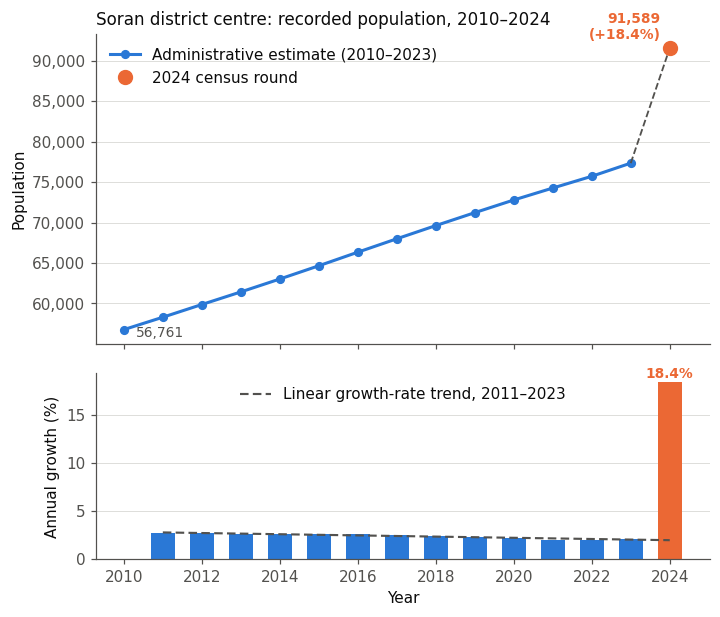

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.2, 6.2), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1.2], "hspace": 0.12})

est = pop[pop.year <= 2023]
ax1.plot(est.year, est.population, "-o", color=PAL["blue"], lw=2, ms=5,
         label="Administrative estimate (2010–2023)")
ax1.plot([2023, 2024], [pop.population.iloc[-2], pop.population.iloc[-1]],
         "--", color=PAL["ink2"], lw=1.2)
ax1.plot([2024], [pop.population.iloc[-1]], "o", color=PAL["orange"], ms=9,
         label="2024 census round")
ax1.annotate(f"{POPV[-1]:,.0f}\n(+{obs_2024:.1f}%)", xy=(2024, POPV[-1]),
             xytext=(-6, 4), textcoords="offset points", ha="right", va="bottom",
             color=PAL["orange"], fontsize=9, fontweight="bold")
ax1.annotate(f"{POPV[0]:,.0f}", xy=(2010, POPV[0]), xytext=(8, -2),
             textcoords="offset points", va="center", color=PAL["ink2"], fontsize=9)
ax1.set_ylabel("Population")
ax1.set_title("Soran district centre: recorded population, 2010–2024", loc="left")
ax1.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
ax1.grid(axis="y"); ax1.set_axisbelow(True); ax1.legend(loc="upper left")

ax2.bar(pre.year, pre.growth_rate_pct, color=PAL["blue"], width=0.62)
ax2.bar([CENSUS_YEAR], [obs_2024], color=PAL["orange"], width=0.62)
ax2.plot(growth.year, gfit.predict(growth[["year"]]), color=PAL["ink2"], lw=1.4,
         ls=(0, (4, 2)), label="Linear growth-rate trend, 2011–2023")
ax2.annotate(f"{obs_2024:.1f}%", xy=(CENSUS_YEAR, obs_2024), xytext=(0, 3),
             textcoords="offset points", ha="center", color=PAL["orange"],
             fontsize=9, fontweight="bold")
ax2.set_ylabel("Annual growth (%)"); ax2.set_xlabel("Year")
ax2.grid(axis="y"); ax2.set_axisbelow(True); ax2.legend(loc="upper center")
ax2.set_xticks(range(2010, 2025, 2))

fig.savefig(FIG / "fig1_population_and_growth.png")
plt.show()

### 2.1 Stationarity diagnostics

ADF unit-root tests, each variable at its own native reporting frequency. The
population test now has 15 annual values rather than 10. Results across variables
differ greatly in power and should not be read as testing the same underlying
temporal process.

In [11]:
from statsmodels.tsa.stattools import adfuller

def adf_row(label, series, note):
    stat, p, lags, nobs, crit, _ = adfuller(np.asarray(series, float), autolag="AIC")
    return {"variable": label, "n": int(nobs + lags + 1), "adf_statistic": stat,
            "p_value": p, "lags_used": int(lags),
            "crit_5pct": crit["5%"],
            "result_alpha_0.05": "Non-stationary" if p >= 0.05 else "Stationary",
            "note": note}

adf = pd.DataFrame([
    adf_row("Population (annual level)", pop.population.values,
            "2010-2024, 15 annual values"),
    adf_row("Population (first difference)", np.diff(pop.population.values),
            "annual increments, 14 values"),
    adf_row("Population growth rate", pop.growth_rate_pct.dropna().values,
            "2011-2024, 14 values"),
    adf_row("Temperature (monthly)", clim.temp_avg_c.values,
            "2015-2024, 120 monthly values"),
    adf_row("Precipitation (monthly)", clim.precip_mm.values,
            "2015-2024, 120 monthly values"),
])
adf.to_csv(TAB / "adf_stationarity_tests.csv", index=False)
adf.round(4)

,variable,n,adf_statistic,p_value,lags_used,crit_5pct,result_alpha_0.05,note
0,Population (annual level),15,3.9941,1.0000,5,-3.2899,Non-stationary,"2010-2024, 15 annual values"
1,Population (first difference),14,1.0953,0.9952,5,-3.3672,Non-stationary,"annual increments, 14 values"
2,Population growth rate,14,-10.6977,0.0000,5,-3.3672,Stationary,"2011-2024, 14 values"
3,Temperature (monthly),120,-1.7157,0.4231,11,-2.8887,Non-stationary,"2015-2024, 120 monthly values"
4,Precipitation (monthly),120,-2.6847,0.0767,9,-2.8882,Non-stationary,"2015-2024, 120 monthly values"


## 3. Out-of-sample validation: rolling-origin design

Expanding-window (leave-future-out) cross-validation, on the annual observations
only. Train on 2010…2010+k, forecast 2010+k+1, for k = 8…14 — **seven genuine
one-step-ahead forecast errors**, up from five in the previous notebook.

Six models are compared. Three are deliberately trivial: with an input series this
smooth, a trivial baseline is the yardstick that shows how little the complex models
add.

| Model | Specification |
|---|---|
| `drift` | random walk with drift — last value + mean historical increment |
| `loglinear` | OLS on log(population) ~ year — constant-growth extrapolation |
| `poly2` | second-degree polynomial in year, fitted on levels (the manuscript's model) |
| `arima` | (p,d,q) grid search on AIC, `seasonal_order=(0,0,0,0)` — an ARIMA, not a SARIMA |
| `mlp_small` | MLP (8,8), α = 0.1, on a fold-internal cubic-spline monthly upsample |
| `mlp_large` | MLP (128,128,128), α = 0.001 — the architecture in the submitted manuscript |

Both MLPs receive the spline upsample **fitted inside the fold**, on training years
only, so no information from the held-out year reaches the interpolation. The scaler
is likewise fitted on training data only and the output layer is linear — there is no
`[0, 0.75]` rescaling.

In [12]:
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.neural_network import MLPRegressor
from scipy.interpolate import CubicSpline
from statsmodels.tsa.statespace.sarimax import SARIMAX

def f_drift(tr_y, tr_p, target):
    return float(tr_p[-1] + np.diff(tr_p).mean() * (target - tr_y[-1]))

def f_loglinear(tr_y, tr_p, target):
    lr = LinearRegression().fit(np.asarray(tr_y).reshape(-1, 1), np.log(tr_p))
    return float(np.exp(lr.predict(np.array([[target]]))[0]))

def f_poly2(tr_y, tr_p, target, degree=2):
    pf = PolynomialFeatures(degree, include_bias=False)
    lr = LinearRegression().fit(pf.fit_transform(np.asarray(tr_y).reshape(-1, 1)), tr_p)
    return float(lr.predict(pf.transform(np.array([[target]])))[0])

def best_arima(y, exog=None, max_p=2, max_d=2, max_q=2):
    """Grid search (p,d,q) on AIC with seasonal_order fixed at (0,0,0,0).
    An annual series has no sub-annual frequency, so no seasonal term is
    estimable and the model is an ARIMA(X), never a SARIMA(X)."""
    rows, best = [], None
    for p in range(max_p + 1):
        for d in range(max_d + 1):
            for q in range(max_q + 1):
                if (p, d, q) == (0, 0, 0):
                    continue
                try:
                    r = SARIMAX(y, exog=exog, order=(p, d, q), seasonal_order=(0, 0, 0, 0),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)
                    if not np.isfinite(r.aic):
                        continue
                    rows.append({"order": f"({p},{d},{q})", "aic": r.aic, "bic": r.bic})
                    if best is None or r.aic < best[1].aic:
                        best = ((p, d, q), r)
                except Exception:
                    pass
    return best, pd.DataFrame(rows).sort_values("aic").reset_index(drop=True)

def _pidx(years):
    return pd.period_range(start=str(years[0]), periods=len(years), freq="Y")

def f_arima(tr_y, tr_p, target):
    (order, res), _ = best_arima(pd.Series(tr_p, index=_pidx(tr_y)))
    steps = target - tr_y[-1]
    return float(res.get_forecast(steps=steps).predicted_mean.iloc[-1]), order

def fit_mlp(tr_y, tr_p, hidden, alpha, seed=SEED):
    """Cubic-spline upsample fitted on the training years ONLY, then an MLP on the
    scaled monthly grid. Scaler fitted on training data only; linear output."""
    cs = CubicSpline(np.asarray(tr_y, float), np.asarray(tr_p, float))
    xm = np.arange(tr_y[0], tr_y[-1] + 1e-9, 1 / 12)
    xs, ys = MinMaxScaler(), MinMaxScaler()
    Xs = xs.fit_transform(xm.reshape(-1, 1))
    Ys = ys.fit_transform(cs(xm).reshape(-1, 1)).ravel()
    m = MLPRegressor(hidden_layer_sizes=hidden, alpha=alpha, max_iter=20000,
                     random_state=seed, learning_rate_init=1e-3).fit(Xs, Ys)
    return m, xs, ys

def mlp_predict(m, xs, ys, target):
    z = m.predict(xs.transform(np.array([[float(target)]]))).reshape(-1, 1)
    return float(ys.inverse_transform(z)[0, 0])

MODELS = ["drift", "loglinear", "poly2", "arima", "mlp_small", "mlp_large"]
MODEL_LABEL = {"drift": "Random walk + drift", "loglinear": "Log-linear trend",
               "poly2": "Polynomial (deg 2)", "arima": "ARIMA (AIC grid)",
               "mlp_small": "MLP (8,8)", "mlp_large": "MLP (128,128,128)"}
print("model helpers defined")

model helpers defined


In [13]:
rows = []
for k in range(MIN_TRAIN, len(YEARS)):
    tr_y, te_y = YEARS[:k], YEARS[k]
    tr_p, actual = POPV[:k], float(POPV[k])
    pred_arima, order = f_arima(tr_y, tr_p, te_y)
    ms, xss, yss = fit_mlp(tr_y, tr_p, (8, 8), 1e-1)
    ml, xsl, ysl = fit_mlp(tr_y, tr_p, (128, 128, 128), 1e-3)
    rows.append({"test_year": te_y, "n_train": k, "actual": actual,
                 "pred_drift": f_drift(tr_y, tr_p, te_y),
                 "pred_loglinear": f_loglinear(tr_y, tr_p, te_y),
                 "pred_poly2": f_poly2(tr_y, tr_p, te_y),
                 "pred_arima": pred_arima, "arima_order": str(order),
                 "pred_mlp_small": mlp_predict(ms, xss, yss, te_y),
                 "pred_mlp_large": mlp_predict(ml, xsl, ysl, te_y)})

rolling = pd.DataFrame(rows)
for m in MODELS:
    rolling[f"err_{m}"] = rolling.actual - rolling[f"pred_{m}"]
rolling.to_csv(TAB / "rolling_origin_forecast_errors.csv", index=False)
rolling[["test_year", "n_train", "actual"] + [f"pred_{m}" for m in MODELS]].round(0)

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,test_year,n_train,actual,pred_drift,pred_loglinear,pred_poly2,pred_arima,pred_mlp_small,pred_mlp_large
0,2018,8,69631.0,69604.0,69845.0,69713.0,77560.0,66272.0,69324.0
1,2019,9,71233.0,71240.0,71573.0,71365.0,71249.0,67642.0,71042.0
2,2020,10,72800.0,72841.0,73290.0,72972.0,72818.0,69014.0,72755.0
3,2021,11,74278.0,74404.0,74988.0,74535.0,77279.0,70346.0,74404.0
4,2022,12,75731.0,75870.0,76646.0,76014.0,75646.0,71658.0,75896.0
5,2023,13,77360.0,77312.0,78270.0,77439.0,77184.0,72936.0,77445.0
6,2024,14,91589.0,78945.0,79926.0,78954.0,79214.0,74165.0,78980.0


In [14]:
def error_summary(df, label):
    out = []
    for m in MODELS:
        e = df[f"err_{m}"]
        out.append({"sample": label, "model": MODEL_LABEL[m], "key": m,
                    "n_forecasts": len(df),
                    "MAPE_%": (e.abs() / df.actual).mean() * 100,
                    "MAE": e.abs().mean(),
                    "RMSE": float(np.sqrt((e ** 2).mean())),
                    "R2": 1 - (e ** 2).sum() / ((df.actual - df.actual.mean()) ** 2).sum()})
    return pd.DataFrame(out).sort_values("RMSE").reset_index(drop=True)

summary_all = error_summary(rolling, f"all folds (2018-{CENSUS_YEAR})")
summary_pre = error_summary(rolling[rolling.test_year < CENSUS_YEAR],
                            f"excluding the {CENSUS_YEAR} rebasing fold")
summary = pd.concat([summary_all, summary_pre], ignore_index=True)
summary.to_csv(TAB / "rolling_origin_error_summary.csv", index=False)
summary.round(3)

,sample,model,key,n_forecasts,MAPE_%,MAE,RMSE,R2
0,all folds (2018-2024),Log-linear trend,loglinear,7,2.504,2177.314,4449.591,0.569
1,all folds (2018-2024),"MLP (128,128,128)",mlp_large,7,2.148,1932.541,4768.484,0.505
2,all folds (2018-2024),Polynomial (deg 2),poly2,7,2.165,1948.486,4778.547,0.503
3,all folds (2018-2024),Random walk + drift,drift,7,2.047,1861.758,4779.756,0.502
4,all folds (2018-2024),ARIMA (AIC grid),arima,7,4.189,3371.439,5670.168,0.300
5,all folds (2018-2024),"MLP (8,8)",mlp_small,7,7.211,5798.345,7499.717,-0.225
6,excluding the 2024 rebasing fold,Random walk + drift,drift,6,0.087,64.640,81.702,0.999
7,excluding the 2024 rebasing fold,"MLP (128,128,128)",mlp_large,6,0.211,153.135,174.542,0.996
8,excluding the 2024 rebasing fold,Polynomial (deg 2),poly2,6,0.227,167.450,185.297,0.995
9,excluding the 2024 rebasing fold,Log-linear trend,loglinear,6,0.800,596.391,654.467,0.937


In [15]:
best_pre = summary_pre.iloc[0]
print("Reading of Table 4 (model comparison):\n")
print(f"  On the inter-censal segment alone, the best model is "
      f"'{best_pre.model}' at MAPE {best_pre['MAPE_%']:.3f}% "
      f"(RMSE {best_pre.RMSE:,.0f}).")
print(f"  A random walk with drift -- one parameter, no training -- reaches MAPE "
      f"{summary_pre.set_index('key').loc['drift', 'MAPE_%']:.3f}%.")
print(f"  The 128x128x128 network the manuscript advocates reaches "
      f"{summary_pre.set_index('key').loc['mlp_large', 'MAPE_%']:.3f}%.\n")
print("  Every model misses the 2024 census point by roughly "
      f"{rolling.query('test_year == @CENSUS_YEAR')[[f'err_{m}' for m in MODELS]].abs().min(axis=1).iloc[0]:,.0f}"
      " persons or more, because no extrapolation of an inter-censal estimate can\n"
      "  anticipate a rebasing.\n")
print("  The sub-0.1% errors are therefore a property of the input series, not a\n"
      "  measure of demographic forecasting skill, and must be reported as such.")

Reading of Table 4 (model comparison):

  On the inter-censal segment alone, the best model is 'Random walk + drift' at MAPE 0.087% (RMSE 82).
  A random walk with drift -- one parameter, no training -- reaches MAPE 0.087%.
  The 128x128x128 network the manuscript advocates reaches 0.211%.

  Every model misses the 2024 census point by roughly 11,663 persons or more, because no extrapolation of an inter-censal estimate can
  anticipate a rebasing.

  The sub-0.1% errors are therefore a property of the input series, not a
  measure of demographic forecasting skill, and must be reported as such.


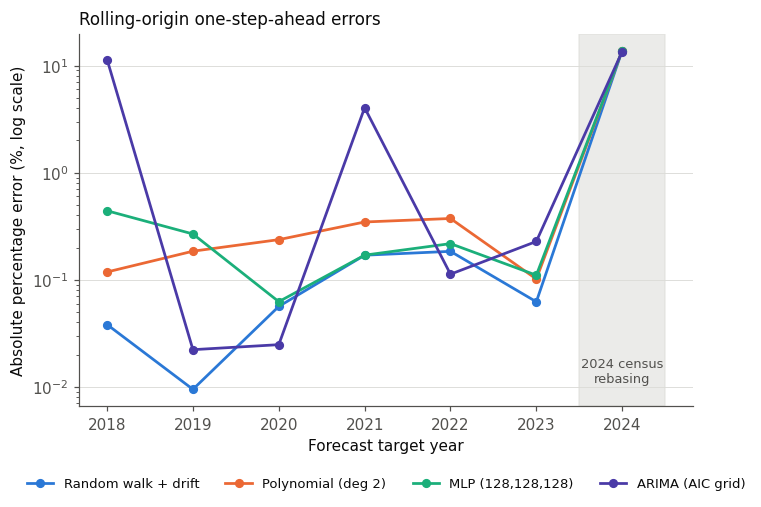

In [16]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
x = np.arange(len(rolling))
order_plot = ["drift", "poly2", "mlp_large", "arima"]
colors = [PAL["blue"], PAL["orange"], PAL["aqua"], PAL["violet"]]
for m, c in zip(order_plot, colors):
    ax.plot(x, (rolling[f"err_{m}"].abs() / rolling.actual) * 100, "-o", ms=5, lw=1.8,
            color=c, label=MODEL_LABEL[m])
ax.axvspan(len(rolling) - 1.5, len(rolling) - 0.5, color=PAL["grid"], alpha=0.55, zorder=0)
ax.annotate("2024 census\nrebasing", xy=(len(rolling) - 1, 0.014), ha="center",
            va="center", fontsize=8.5, color=PAL["ink2"])
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(rolling.test_year)
ax.set_xlabel("Forecast target year"); ax.set_ylabel("Absolute percentage error (%, log scale)")
ax.set_title("Rolling-origin one-step-ahead errors", loc="left")
ax.grid(axis="y"); ax.set_axisbelow(True)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.16), fontsize=8.6)
fig.savefig(FIG / "fig3_rolling_origin_errors.png")
plt.show()

### 3.1 Diebold–Mariano tests

Pairwise DM tests on the rolling-origin errors, with the Harvey–Leybourne–Newbold
(1997) small-sample correction. `n_independent_forecasts` is reported alongside every
statistic: with seven folds — six once the rebasing year is excluded — no DM result
here can support a claim of the "p < 0.0001" kind made in the original submission.

In [17]:
from scipy import stats as sstats

def diebold_mariano(e1, e2, h=1, power=2):
    """DM statistic with the Harvey-Leybourne-Newbold small-sample correction."""
    e1, e2 = np.asarray(e1, float), np.asarray(e2, float)
    d = np.abs(e1) ** power - np.abs(e2) ** power
    n = len(d)
    if n < 3:
        return np.nan, np.nan, n
    var_d = np.var(d, ddof=0)
    for lag in range(1, h):
        var_d += 2 * np.cov(d[:-lag], d[lag:])[0, 1]
    var_d /= n
    if not np.isfinite(var_d) or var_d <= 0:
        return np.nan, np.nan, n
    hln = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    stat = d.mean() / np.sqrt(var_d) * hln
    return stat, 2 * (1 - sstats.t.cdf(abs(stat), df=n - 1)), n

dm_rows = []
for label, df in [(f"all folds (2018-{CENSUS_YEAR})", rolling),
                  (f"excluding the {CENSUS_YEAR} rebasing fold",
                   rolling[rolling.test_year < CENSUS_YEAR])]:
    for i, m1 in enumerate(MODELS):
        for m2 in MODELS[i + 1:]:
            stat, p, n = diebold_mariano(df[f"err_{m1}"], df[f"err_{m2}"])
            dm_rows.append({"sample": label, "model_1": MODEL_LABEL[m1],
                            "model_2": MODEL_LABEL[m2], "dm_stat": stat,
                            "p_value": p, "n_independent_forecasts": n,
                            "significant_at_5pct": bool(np.isfinite(p) and p < 0.05)})

dm = pd.DataFrame(dm_rows)
dm.to_csv(TAB / "diebold_mariano_results.csv", index=False)
print(f"{dm.significant_at_5pct.sum()} of {len(dm)} pairwise comparisons reach p < 0.05 "
      f"(n = 6-7 independent forecasts).")
dm.round(4)

8 of 30 pairwise comparisons reach p < 0.05 (n = 6-7 independent forecasts).


,sample,model_1,model_2,dm_stat,p_value,n_independent_forecasts,significant_at_5pct
0,all folds (2018-2024),Random walk + drift,Log-linear trend,0.8779,0.4138,7,False
1,all folds (2018-2024),Random walk + drift,Polynomial (deg 2),0.2886,0.7826,7,False
2,all folds (2018-2024),Random walk + drift,ARIMA (AIC grid),-1.0233,0.3456,7,False
3,all folds (2018-2024),Random walk + drift,"MLP (8,8)",-1.8140,0.1196,7,False
4,all folds (2018-2024),Random walk + drift,"MLP (128,128,128)",0.8152,0.4461,7,False
5,all folds (2018-2024),Log-linear trend,Polynomial (deg 2),-0.8846,0.4104,7,False
6,all folds (2018-2024),Log-linear trend,ARIMA (AIC grid),-1.4052,0.2096,7,False
7,all folds (2018-2024),Log-linear trend,"MLP (8,8)",-1.6664,0.1467,7,False
8,all folds (2018-2024),Log-linear trend,"MLP (128,128,128)",-0.8801,0.4126,7,False
9,all folds (2018-2024),Polynomial (deg 2),ARIMA (AIC grid),-1.0256,0.3447,7,False


### 3.2 Comparison with elementary benchmarks

Three deliberately simple forecasts — a naive last-observation carry-forward, a
random walk with drift, and an OLS linear trend on year — are run through the same
seven rolling-origin folds, together with the fitted specifications. Two scale-free
measures are added:

* **MASE** — each fold's absolute error divided by the mean one-step naive absolute
  error inside that fold's own training window, then averaged. Values below 1 mean the
  forecast beats a within-sample naive step.
* **RelMAE** — mean absolute error relative to the naive benchmark on the same targets.

Reported twice: over all seven folds, and over the six inter-censal folds alone. The
second panel is the one that shows what these models are actually doing, and it is
unflattering: on the administratively smoothed segment every method is accurate
because the target is smooth, and on the rebasing year every method fails.

In [18]:
def f_naive(tr_y, tr_p, target):
    return float(tr_p[-1])

def f_lintrend(tr_y, tr_p, target):
    lr = LinearRegression().fit(np.asarray(tr_y).reshape(-1, 1), tr_p)
    return float(lr.predict(np.array([[target]]))[0])

BENCH = {"naive": f_naive, "lintrend": f_lintrend}
BENCH_LABEL = {"naive": "Naive (last observation)", "lintrend": "Linear trend (OLS on year)"}

scale_rows = []
for k in range(MIN_TRAIN, len(YEARS)):
    tr_y, te_y, tr_p = YEARS[:k], YEARS[k], POPV[:k]
    row = {"test_year": te_y,
           "naive_scale": float(np.mean(np.abs(np.diff(tr_p))))}
    for key, fn in BENCH.items():
        row[f"pred_{key}"] = fn(tr_y, tr_p, te_y)
    scale_rows.append(row)
extra = pd.DataFrame(scale_rows)

bench = rolling.merge(extra, on="test_year")
ALL_MODELS = list(BENCH) + MODELS
ALL_LABEL = {**BENCH_LABEL, **MODEL_LABEL}
for m in BENCH:
    bench[f"err_{m}"] = bench.actual - bench[f"pred_{m}"]

def bench_summary(df, label):
    naive_mae = df["err_naive"].abs().mean()
    out = []
    for m in ALL_MODELS:
        e = df[f"err_{m}"]
        out.append({"sample": label, "model": ALL_LABEL[m], "key": m,
                    "n_forecasts": len(df),
                    "MAPE_%": (e.abs() / df.actual).mean() * 100,
                    "MAE": e.abs().mean(),
                    "RMSE": float(np.sqrt((e ** 2).mean())),
                    "R2": 1 - (e ** 2).sum() / ((df.actual - df.actual.mean()) ** 2).sum(),
                    "MASE": (e.abs() / df.naive_scale).mean(),
                    "RelMAE_vs_naive": e.abs().mean() / naive_mae})
    return pd.DataFrame(out).sort_values("MASE").reset_index(drop=True)

benchmarks = pd.concat([
    bench_summary(bench, f"all folds (2018-{CENSUS_YEAR})"),
    bench_summary(bench[bench.test_year < CENSUS_YEAR],
                  f"excluding the {CENSUS_YEAR} rebasing fold")], ignore_index=True)
benchmarks.to_csv(TAB / "benchmark_comparison.csv", index=False)
benchmarks.round(3)

,sample,model,key,n_forecasts,MAPE_%,MAE,RMSE,R2,MASE,RelMAE_vs_naive
0,all folds (2018-2024),Random walk + drift,drift,7,2.047,1861.758,4779.756,0.502,1.175,0.552
1,all folds (2018-2024),Linear trend (OLS on year),lintrend,7,2.095,1893.864,4731.355,0.512,1.195,0.562
2,all folds (2018-2024),"MLP (128,128,128)",mlp_large,7,2.148,1932.541,4768.484,0.505,1.219,0.573
3,all folds (2018-2024),Polynomial (deg 2),poly2,7,2.165,1948.486,4778.547,0.503,1.229,0.578
4,all folds (2018-2024),Log-linear trend,loglinear,7,2.504,2177.314,4449.591,0.569,1.372,0.646
5,all folds (2018-2024),ARIMA (AIC grid),arima,7,4.189,3371.439,5670.168,0.300,2.115,1.000
6,all folds (2018-2024),Naive (last observation),naive,7,4.042,3370.000,5569.035,0.324,2.119,1.000
7,all folds (2018-2024),"MLP (8,8)",mlp_small,7,7.211,5798.345,7499.717,-0.225,3.640,1.721
8,excluding the 2024 rebasing fold,Random walk + drift,drift,6,0.087,64.640,81.702,0.999,0.040,0.041
9,excluding the 2024 rebasing fold,Linear trend (OLS on year),lintrend,6,0.167,124.041,147.083,0.997,0.078,0.080


In [19]:
fold_errors = pd.DataFrame({"model": [ALL_LABEL[m] for m in ALL_MODELS]})
for _, r in bench.iterrows():
    fold_errors[str(int(r.test_year))] = [abs(r[f"err_{m}"]) for m in ALL_MODELS]
fold_errors.to_csv(TAB / "fold_level_absolute_errors.csv", index=False)

print("Fold-level absolute errors (persons). Note the 2024 column: no specification\n"
      "is within an order of magnitude of the others' inter-censal errors, because the\n"
      "census rebasing is not a forecastable quantity.\n")
fold_errors.round(0)

Fold-level absolute errors (persons). Note the 2024 column: no specification
is within an order of magnitude of the others' inter-censal errors, because the
census rebasing is not a forecastable quantity.



,model,2018,2019,2020,2021,2022,2023,2024
0,Naive (last observation),1632.0,1602.0,1567.0,1478.0,1453.0,1629.0,14229.0
1,Linear trend (OLS on year),110.0,57.0,12.0,146.0,260.0,161.0,12513.0
2,Random walk + drift,27.0,7.0,41.0,126.0,139.0,48.0,12644.0
3,Log-linear trend,214.0,340.0,490.0,710.0,915.0,910.0,11663.0
4,Polynomial (deg 2),82.0,132.0,172.0,257.0,283.0,79.0,12635.0
5,ARIMA (AIC grid),7929.0,16.0,18.0,3001.0,85.0,176.0,12375.0
6,"MLP (8,8)",3359.0,3591.0,3786.0,3932.0,4073.0,4424.0,17424.0
7,"MLP (128,128,128)",307.0,191.0,45.0,126.0,165.0,85.0,12609.0


## 4. Climate and demography

The manuscript's "decoupling" claim is re-tested here at the annual level, on
detrended year-on-year growth rates, at lags 0–2, with Spearman ρ — no interpolated
monthly population enters the test.

**This test cannot be informative, and the manuscript should say so.** The
population values for 2015–2023 are generated by a smooth administrative rule
(§2), so their year-on-year variation contains no independent demographic signal;
2024 is a rebasing rather than a demographic response. A null result here is
evidence about the data, not about Soran. The correct wording is that the available
series *cannot resolve* a climate–demography association at annual resolution — not
that the two are decoupled.

In [20]:
from scipy.stats import spearmanr
from scipy.signal import detrend

overlap = (pop[["year", "population", "density_per_km2"]]
           .merge(clim_annual, on="year").sort_values("year").reset_index(drop=True))
CLIM_VARS = ["temp_avg_c", "precip_total_mm", "humidity_avg_pct", "pan_evap_total_mm"]

rows = []
pop_growth = detrend(overlap.population.pct_change().dropna().values)
for lag in (0, 1, 2):
    shifted = overlap[CLIM_VARS].shift(lag).iloc[1:].reset_index(drop=True)
    n = min(len(pop_growth), len(shifted.dropna()))
    if n < 4:
        continue
    for v in CLIM_VARS:
        x = shifted[v].dropna().values[:n]
        rho, p = spearmanr(detrend(pop_growth[-n:]), detrend(x))
        rows.append({"lag_years": lag, "climate_variable": v, "n_pairs": n,
                     "spearman_rho": rho, "p_value": p,
                     "significant_at_5pct": bool(p < 0.05)})

decoupling = pd.DataFrame(rows)

# Twelve tests are run (4 variables x 3 lags), so raw p-values overstate significance.
# Holm-Bonferroni and Benjamini-Hochberg adjustments are reported alongside.
from statsmodels.stats.multitest import multipletests
decoupling["p_holm"] = multipletests(decoupling.p_value, method="holm")[1]
decoupling["p_fdr_bh"] = multipletests(decoupling.p_value, method="fdr_bh")[1]
decoupling["significant_after_holm"] = decoupling.p_holm < 0.05
decoupling.to_csv(TAB / "decoupling_annual_lagged_correlation.csv", index=False)
print(f"Effective annual sample: N = {len(overlap)} years "
      f"({len(overlap) - 1} growth-rate pairs).")
print(f"Significant (raw p < 0.05) lag/variable combinations: "
      f"{int(decoupling.significant_at_5pct.sum())} of {len(decoupling)}; "
      f"after Holm-Bonferroni correction for the {len(decoupling)} tests: "
      f"{int(decoupling.significant_after_holm.sum())}.")
decoupling.round(4)

Effective annual sample: N = 10 years (9 growth-rate pairs).
Significant (raw p < 0.05) lag/variable combinations: 1 of 12; after Holm-Bonferroni correction for the 12 tests: 0.


,lag_years,climate_variable,n_pairs,spearman_rho,p_value,significant_at_5pct,p_holm,p_fdr_bh,significant_after_holm
0,0,temp_avg_c,9,0.6000,0.0876,False,0.9639,0.5257,False
1,0,precip_total_mm,9,0.4500,0.2242,False,1.0000,0.6988,False
2,0,humidity_avg_pct,9,0.7833,0.0125,True,0.1502,0.1502,False
3,0,pan_evap_total_mm,9,-0.3500,0.3558,False,1.0000,0.8497,False
4,1,temp_avg_c,9,-0.1333,0.7324,False,1.0000,0.8497,False
5,1,precip_total_mm,9,0.1333,0.7324,False,1.0000,0.8497,False
6,1,humidity_avg_pct,9,0.2667,0.4879,False,1.0000,0.8497,False
7,1,pan_evap_total_mm,9,-0.0333,0.9322,False,1.0000,0.9322,False
8,2,temp_avg_c,8,-0.1429,0.7358,False,1.0000,0.8497,False
9,2,precip_total_mm,8,-0.1905,0.6514,False,1.0000,0.8497,False


Monthly temperature-precipitation association (n = 120): Spearman rho = -0.806, p = 1.30e-28


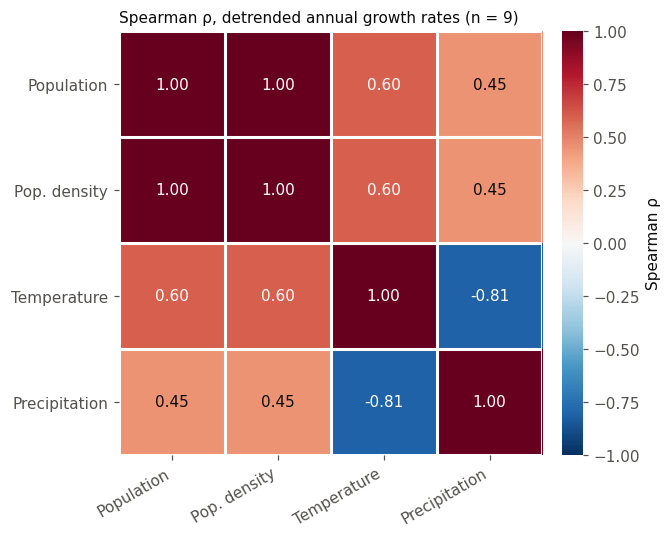

,Population,Pop. density,Temperature,Precipitation
Population,1.00,1.00,0.600,0.450
Pop. density,1.00,1.00,0.600,0.450
Temperature,0.60,0.60,1.000,-0.806
Precipitation,0.45,0.45,-0.806,1.000


In [21]:
# Figure 2 -- 4x4 correlation matrix, same four variables as the submitted figure.
labels = ["Population", "Pop. density", "Temperature", "Precipitation"]
g_pop  = detrend(overlap.population.pct_change().dropna().values)
g_den  = detrend(overlap.density_per_km2.pct_change().dropna().values)
t_dt   = detrend(overlap.temp_avg_c.values[1:])
p_dt   = detrend(overlap.precip_total_mm.values[1:])
series = dict(zip(labels, [g_pop, g_den, t_dt, p_dt]))

M = pd.DataFrame(np.eye(4), index=labels, columns=labels)
for a in labels:
    for b in labels:
        if a != b:
            M.loc[a, b] = spearmanr(series[a], series[b])[0]
# Temperature-precipitation keeps its monthly relationship: genuine intra-annual
# structure, no population-related small-N concern.
tp, tp_p = spearmanr(clim.temp_avg_c, clim.precip_mm)
print(f"Monthly temperature-precipitation association (n = {len(clim)}): "
      f"Spearman rho = {tp:.3f}, p = {tp_p:.2e}")
M.loc["Temperature", "Precipitation"] = M.loc["Precipitation", "Temperature"] = tp

fig, ax = plt.subplots(figsize=(5.6, 5.0))
im = ax.imshow(M.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(4), labels, rotation=30, ha="right")
ax.set_yticks(range(4), labels)
for i in range(4):
    for j in range(4):
        v = M.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=10,
                color="white" if abs(v) > 0.55 else PAL["ink"])
ax.set_title("Spearman ρ, detrended annual growth rates (n = 9)", loc="left", fontsize=10)
ax.set_xticks(np.arange(-.5, 4, 1), minor=True)
ax.set_yticks(np.arange(-.5, 4, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("Spearman ρ"); cb.outline.set_visible(False)
fig.savefig(FIG / "fig2_correlation_heatmap.png")
plt.show()
M.round(3)

## 5. Forecasts, 2025–2030

Five specifications are computed. They are not equally defensible, and the table
that follows makes the ranking explicit rather than presenting a "consensus range"
across models — the spread between competing point forecasts is not a prediction
interval, as Reviewer 1 correctly noted.

| Specification | Description | Status |
|---|---|---|
| **A. Growth-rate projection** | growth-rate trend estimated on 2011–2023, compounded forward from the 2024 census level | **recommended headline** |
| B. ARIMA + level shift | ARIMA(p,d,q) on 2010–2024 with a step dummy at 2024 | corroborating |
| C. Polynomial (deg 2), full sample | the manuscript's model, fitted to 2010–2024 | reported as a failure case |
| D. Log-linear, full sample | constant-growth extrapolation on 2010–2024 | reported as a failure case |
| E. Polynomial (deg 2), 2010–2023 | the manuscript's model without the census year | shows the sensitivity |

Specifications C, D and E are kept **because they fail**, and visibly. Fitted across
the 2024 discontinuity, C and D return 2025 values *below* the observed 2024
population — a curve-fitting artefact of averaging a level shift into a trend. That
is the direct, demonstrable answer to the reviewer's question about whether the
polynomial specification is appropriate.

In [22]:
# --- A. growth-rate projection anchored on the census level -----------------
g_hat = np.array([float(gfit.predict([[y]])[0]) / 100 for y in FORECAST_YEARS])
g_hat = np.clip(g_hat, 0.005, None)
base = float(POPV[-1])
spec_A = base * np.cumprod(1 + g_hat)

# Scenario band. The uncertainty that matters is not the residual scatter of a
# near-deterministic administrative series (which would give a band of +/-100
# persons) but whether the observed decline in the growth rate continues.
g_high = np.full(len(FORECAST_YEARS), pre.growth_rate_pct.iloc[-1] / 100)      # holds at 2023 rate
g_low  = np.clip(g_hat - (np.arange(1, len(FORECAST_YEARS) + 1)
                          * abs(gfit.coef_[0]) / 100), 0.0, None)              # decline twice as fast
spec_A_high = base * np.cumprod(1 + g_high)
spec_A_low  = base * np.cumprod(1 + g_low)

# --- B. ARIMA with a step dummy at the census year --------------------------
step = (np.asarray(YEARS) >= CENSUS_YEAR).astype(float).reshape(-1, 1)
(order_B, res_B), order_table = best_arima(pd.Series(POPV, index=_pidx(YEARS)), exog=step)
fc_B = res_B.get_forecast(steps=len(FORECAST_YEARS),
                          exog=np.ones((len(FORECAST_YEARS), 1)))
spec_B = fc_B.predicted_mean.values
ci_B = np.asarray(fc_B.conf_int(alpha=0.05))
order_table.assign(specification="B_arima_with_step_dummy").to_csv(
    TAB / "arima_order_selection.csv", index=False)

# --- C / D / E: the manuscript's specifications ------------------------------
spec_C = np.array([f_poly2(YEARS, POPV, y) for y in FORECAST_YEARS])
spec_D = np.array([f_loglinear(YEARS, POPV, y) for y in FORECAST_YEARS])
spec_E = np.array([f_poly2(YEARS[:-1], POPV[:-1], y) for y in FORECAST_YEARS])

specs = pd.DataFrame({
    "year": FORECAST_YEARS,
    "A_growth_projection": spec_A,
    "A_low": spec_A_low, "A_high": spec_A_high,
    "B_arima_step": spec_B, "B_95ci_lo": ci_B[:, 0], "B_95ci_hi": ci_B[:, 1],
    "C_poly2_full": spec_C, "D_loglinear_full": spec_D, "E_poly2_excl_2024": spec_E,
})
specs.to_csv(TAB / "forecast_specification_comparison.csv", index=False)
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera as jb_test

resid_B = np.asarray(res_B.resid, float)[2:]          # drop the differencing burn-in
lb_p = float(acorr_ljungbox(resid_B, lags=[min(4, len(resid_B) - 2)],
                            return_df=True)["lb_pvalue"].iloc[0])
jb_p = float(jb_test(resid_B)[1])
print(f"ARIMA order selected for specification B: {order_B} "
      f"with seasonal_order=(0,0,0,0)  ->  ARIMAX, not SARIMAX")
print(f"  residual diagnostics: Ljung-Box p = {lb_p:.3f}; Jarque-Bera p = {jb_p:.3f}")
print(f"  step-dummy coefficient (2024 level shift) = "
      f"{float(res_B.params.iloc[0]):,.0f} persons")
specs.round(0)

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA order selected for specification B: (0, 2, 2) with seasonal_order=(0,0,0,0)  ->  ARIMAX, not SARIMAX
  residual diagnostics: Ljung-Box p = 0.883; Jarque-Bera p = 0.761
  step-dummy coefficient (2024 level shift) = 12,564 persons


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,year,A_growth_projection,A_low,A_high,B_arima_step,B_95ci_lo,B_95ci_hi,C_poly2_full,D_loglinear_full,E_poly2_excl_2024
0,2025,93342.0,93285.0,93559.0,93191.0,93093.0,93289.0,88083.0,84891.0,80502.0
1,2026,95071.0,94897.0,95572.0,94794.0,94574.0,95013.0,91520.0,87244.0,82044.0
2,2027,96773.0,96420.0,97627.0,96396.0,96094.0,96698.0,95137.0,89663.0,83580.0
3,2028,98445.0,97847.0,99727.0,97998.0,97625.0,98371.0,98934.0,92149.0,85110.0
4,2029,100085.0,99173.0,101873.0,99600.0,99162.0,100039.0,102910.0,94704.0,86634.0
5,2030,101691.0,100395.0,104064.0,101203.0,100703.0,101702.0,107066.0,97330.0,88151.0


In [23]:
print(f"Observed {CENSUS_YEAR} population: {base:,.0f}\n")
for name, v in [("C. Polynomial deg 2, 2010-2024", spec_C),
                ("D. Log-linear, 2010-2024", spec_D)]:
    print(f"  {name}: 2025 = {v[0]:,.0f}  "
          f"({'BELOW' if v[0] < base else 'above'} the observed 2024 level "
          f"by {abs(v[0]-base):,.0f})")
print()
print("  A polynomial or log-linear trend fitted across the 2024 rebasing splits the")
print("  difference between the pre-census estimates and the census level, and so")
print("  projects a population decline that no component of the data supports.")
print("  Specifications A and B, which model the rebasing as a level shift, agree to")
print(f"  within {abs(spec_A[-1]-spec_B[-1]):,.0f} persons in 2030 "
      f"({abs(spec_A[-1]-spec_B[-1])/spec_A[-1]*100:.2f}%).")

Observed 2024 population: 91,589

  C. Polynomial deg 2, 2010-2024: 2025 = 88,083  (BELOW the observed 2024 level by 3,506)
  D. Log-linear, 2010-2024: 2025 = 84,891  (BELOW the observed 2024 level by 6,698)

  A polynomial or log-linear trend fitted across the 2024 rebasing splits the
  difference between the pre-census estimates and the census level, and so
  projects a population decline that no component of the data supports.
  Specifications A and B, which model the rebasing as a level shift, agree to
  within 488 persons in 2030 (0.48%).


In [24]:
# Headline table for the manuscript (replaces the old "Consensus Range" table).
final = pd.DataFrame({
    "year": FORECAST_YEARS,
    "population_forecast": np.round(spec_A).astype(int),
    "scenario_low": np.round(spec_A_low).astype(int),
    "scenario_high": np.round(spec_A_high).astype(int),
    "assumed_growth_rate_pct": np.round(g_hat * 100, 3),
    "corroborating_arima_step": np.round(spec_B).astype(int),
})
final["change_vs_2024"] = final.population_forecast - int(base)
final["cumulative_growth_vs_2024_pct"] = (
    (final.population_forecast / base - 1) * 100).round(2)
final.to_csv(TAB / "final_forecast_2025_2030.csv", index=False)
final

,year,population_forecast,scenario_low,scenario_high,assumed_growth_rate_pct,corroborating_arima_step,change_vs_2024,cumulative_growth_vs_2024_pct
0,2025,93342,93285,93559,1.914,93191,1753,1.91
1,2026,95071,94897,95572,1.852,94794,3482,3.80
2,2027,96773,96420,97627,1.790,96396,5184,5.66
3,2028,98445,97847,99727,1.728,97998,6856,7.49
4,2029,100085,99173,101873,1.666,99600,8496,9.28
5,2030,101691,100395,104064,1.604,101203,10102,11.03


### 5.1 In-sample fit and the fitted growth equation

Two fitted equations belong in the manuscript. The first is the growth-rate trend that
drives the recommended projection; the second is the second-degree polynomial in
levels, reported so that the specification-failure argument in §5 can be stated with
its coefficients.

In [25]:
t_all = np.asarray(YEARS) - YEARS[0]      # t = 0 at 2010

# (i) growth-rate trend, estimated on 2011-2023 (drives specification A)
b1, b0 = float(gfit.coef_[0]), float(gfit.intercept_)
g_at = lambda year: b0 + b1 * year
print("Growth-rate equation (specification A), fitted on 2011-2023:")
print(f"  g(year) [%] = {b0:,.3f} + ({b1:.5f}) x year")
print(f"  equivalently g(t) [%] = {g_at(YEARS[0]):.3f} - {abs(b1):.4f} t,  t = year - {YEARS[0]}")
print(f"  R2 = {gfit.score(pre[['year']], pre.growth_rate_pct):.3f}; "
      f"residual SD = {g_resid_sd:.3f} pp\n")

# (ii) second-degree polynomial in levels, full sample (the manuscript's model)
pf_is = PolynomialFeatures(2, include_bias=False)
X_is = pf_is.fit_transform(t_all.reshape(-1, 1))
lr_is = LinearRegression().fit(X_is, POPV)
fit_is = lr_is.predict(X_is)
c0, (c1, c2) = float(lr_is.intercept_), lr_is.coef_
r2_is = 1 - ((POPV - fit_is) ** 2).sum() / ((POPV - POPV.mean()) ** 2).sum()
mape_is = float(np.mean(np.abs(POPV - fit_is) / POPV) * 100)
rmse_is = float(np.sqrt(np.mean((POPV - fit_is) ** 2)))
print("Polynomial growth equation (in-sample, 2010-2024, t = year - 2010):")
print(f"  P(t) = {c0:,.0f} + {c1:,.0f} t + {c2:,.0f} t^2")
print(f"  in-sample R2 = {r2_is:.3f}; MAPE = {mape_is:.2f}%; RMSE = {rmse_is:,.0f}\n")

# the same polynomial fitted without the census year, for the contrast
X_e = pf_is.fit_transform(t_all[:-1].reshape(-1, 1))
lr_e = LinearRegression().fit(X_e, POPV[:-1])
fit_e = lr_e.predict(X_e)
r2_e = 1 - ((POPV[:-1] - fit_e) ** 2).sum() / ((POPV[:-1] - POPV[:-1].mean()) ** 2).sum()
print(f"Same polynomial on 2010-2023 only: in-sample R2 = {r2_e:.4f}, "
      f"MAPE = {np.mean(np.abs(POPV[:-1]-fit_e)/POPV[:-1])*100:.3f}% -- an almost exact fit,")
print("which is a restatement of the finding in section 2: that segment is a smooth rule.")

insample = pd.DataFrame([
    {"quantity": "growth-rate intercept b0 (%)", "value": b0},
    {"quantity": "growth-rate slope b1 (pp per year)", "value": b1},
    {"quantity": "growth-rate trend R2 (2011-2023)", "value":
        gfit.score(pre[["year"]], pre.growth_rate_pct)},
    {"quantity": "polynomial c0 (persons, t=0 at 2010)", "value": c0},
    {"quantity": "polynomial c1 (persons/yr)", "value": c1},
    {"quantity": "polynomial c2 (persons/yr2)", "value": c2},
    {"quantity": "polynomial in-sample R2, 2010-2024", "value": r2_is},
    {"quantity": "polynomial in-sample MAPE %, 2010-2024", "value": mape_is},
    {"quantity": "polynomial in-sample RMSE, 2010-2024", "value": rmse_is},
    {"quantity": "polynomial in-sample R2, 2010-2023", "value": r2_e},
])
insample.to_csv(TAB / "in_sample_fit_statistics.csv", index=False)
insample.round(4)

Growth-rate equation (specification A), fitted on 2011-2023:
  g(year) [%] = 127.554 + (-0.06204) x year
  equivalently g(t) [%] = 2.845 - 0.0620 t,  t = year - 2010
  R2 = 0.882; residual SD = 0.092 pp

Polynomial growth equation (in-sample, 2010-2024, t = year - 2010):
  P(t) = 58,091 + 652 t + 90 t^2
  in-sample R2 = 0.925; MAPE = 2.14%; RMSE = 2,388

Same polynomial on 2010-2023 only: in-sample R2 = 0.9998, MAPE = 0.107% -- an almost exact fit,
which is a restatement of the finding in section 2: that segment is a smooth rule.


,quantity,value
0,growth-rate intercept b0 (%),127.5540
1,growth-rate slope b1 (pp per year),-0.0620
2,growth-rate trend R2 (2011-2023),0.8823
3,"polynomial c0 (persons, t=0 at 2010)",58090.6706
4,polynomial c1 (persons/yr),651.6792
5,polynomial c2 (persons/yr2),89.8548
6,"polynomial in-sample R2, 2010-2024",0.9250
7,"polynomial in-sample MAPE %, 2010-2024",2.1385
8,"polynomial in-sample RMSE, 2010-2024",2388.1108
9,"polynomial in-sample R2, 2010-2023",0.9998


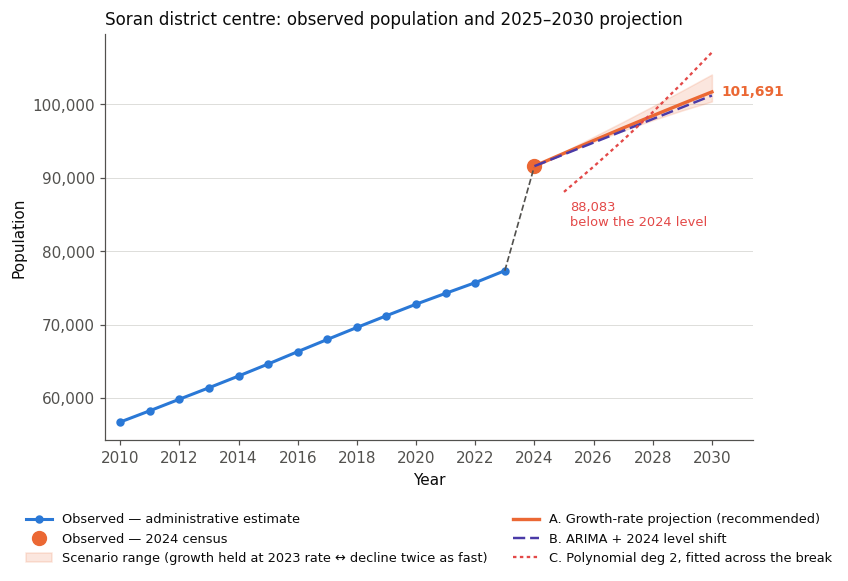

In [26]:
fig, ax = plt.subplots(figsize=(7.6, 4.8))

ax.plot(pop.year[pop.year <= 2023], POPV[:-1], "-o", color=PAL["blue"], lw=2, ms=4.5,
        label="Observed — administrative estimate")
ax.plot([2024], [base], "o", color=PAL["orange"], ms=9, label="Observed — 2024 census")
ax.plot([2023, 2024], [POPV[-2], base], "--", color=PAL["ink2"], lw=1.1)

fy = np.array(FORECAST_YEARS)
ax.fill_between(fy, spec_A_low, spec_A_high, color=PAL["orange"], alpha=0.16,
                label="Scenario range (growth held at 2023 rate ↔ decline twice as fast)")
ax.plot(np.r_[2024, fy], np.r_[base, spec_A], "-", color=PAL["orange"], lw=2.2,
        label="A. Growth-rate projection (recommended)")
ax.plot(np.r_[2024, fy], np.r_[base, spec_B], ls=(0, (5, 2)), color=PAL["violet"], lw=1.6,
        label="B. ARIMA + 2024 level shift")
ax.plot(fy, spec_C, ls=(0, (1.5, 1.5)), color=PAL["red"], lw=1.5,
        label="C. Polynomial deg 2, fitted across the break")

ax.annotate(f"{spec_A[-1]:,.0f}", xy=(2030, spec_A[-1]), xytext=(6, 0),
            textcoords="offset points", va="center", color=PAL["orange"],
            fontsize=9, fontweight="bold")
ax.annotate(f"{spec_C[0]:,.0f}\nbelow the 2024 level", xy=(2025, spec_C[0]),
            xytext=(4, -22), textcoords="offset points", color=PAL["red"], fontsize=8.5)

ax.set_xlabel("Year"); ax.set_ylabel("Population")
ax.set_title("Soran district centre: observed population and 2025–2030 projection",
             loc="left")
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y"); ax.set_axisbelow(True)
ax.set_xlim(2009.5, 2031.4)
ax.set_xticks(range(2010, 2031, 2))
ax.legend(fontsize=8.4, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
fig.savefig(FIG / "fig4_final_forecast.png")
plt.show()

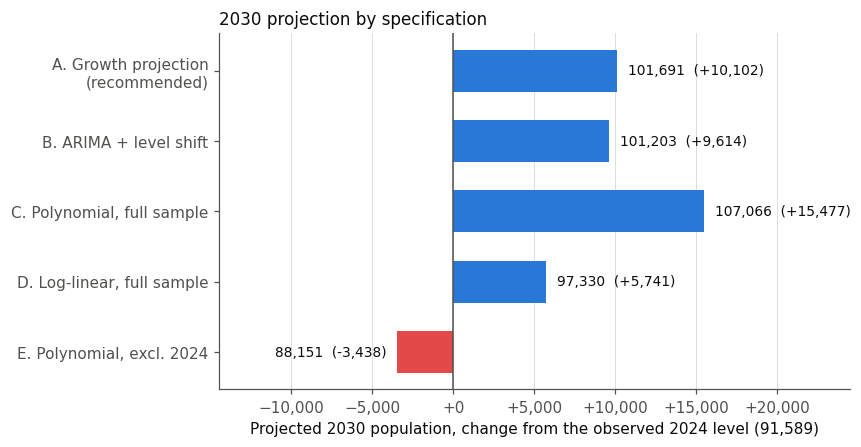

In [27]:
fig, ax = plt.subplots(figsize=(7.4, 4.2))
bars = [("A. Growth projection\n(recommended)", spec_A[-1]),
        ("B. ARIMA + level shift", spec_B[-1]),
        ("C. Polynomial, full sample", spec_C[-1]),
        ("D. Log-linear, full sample", spec_D[-1]),
        ("E. Polynomial, excl. 2024", spec_E[-1])]
delta = np.array([b[1] for b in bars]) - base
y = np.arange(len(bars))
cols = [PAL["blue"] if d >= 0 else PAL["red"] for d in delta]
ax.barh(y, delta, color=cols, height=0.6)
ax.axvline(0, color=PAL["ink2"], lw=1.0)
for yi, d, (_, v) in zip(y, delta, bars):
    off = 7 if d >= 0 else -7
    ax.annotate(f"{v:,.0f}  ({d:+,.0f})", xy=(d, yi), xytext=(off, 0),
                textcoords="offset points", va="center",
                ha="left" if d >= 0 else "right", fontsize=9, color=PAL["ink"])
ax.set_yticks(y, [b[0] for b in bars])
ax.invert_yaxis()
ax.set_xlabel(f"Projected 2030 population, change from the observed {CENSUS_YEAR} "
              f"level ({base:,.0f})")
ax.set_title("2030 projection by specification", loc="left")
ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:+,.0f}"))
ax.set_xlim(delta.min() - 11000, delta.max() + 9000)
ax.grid(axis="x"); ax.set_axisbelow(True)
fig.savefig(FIG / "fig5_specification_comparison.png")
plt.show()

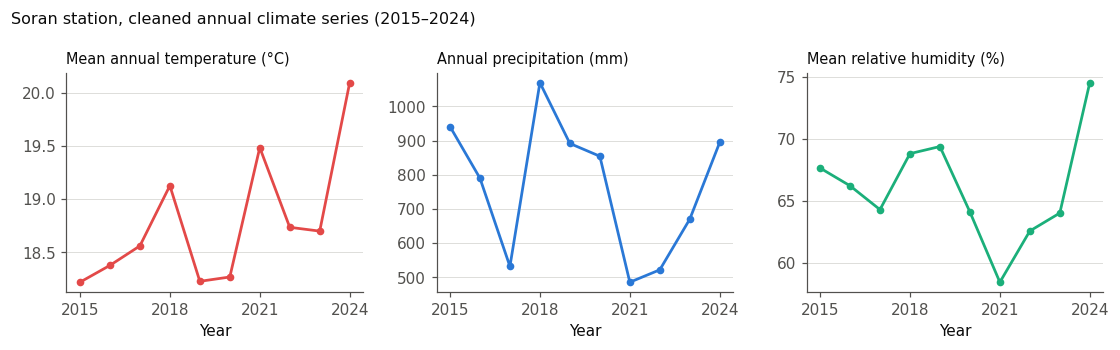

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.2))
panels = [("temp_avg_c", "Mean annual temperature (°C)", PAL["red"]),
          ("precip_total_mm", "Annual precipitation (mm)", PAL["blue"]),
          ("humidity_avg_pct", "Mean relative humidity (%)", PAL["aqua"])]
for ax, (col, title, c) in zip(axes, panels):
    ax.plot(clim_annual.year, clim_annual[col], "-o", color=c, lw=1.8, ms=4)
    ax.set_title(title, loc="left", fontsize=9.5)
    ax.grid(axis="y"); ax.set_axisbelow(True)
    ax.set_xticks(range(2015, 2025, 3))
    ax.set_xlabel("Year")
fig.suptitle("Soran station, cleaned annual climate series (2015–2024)",
             x=0.005, ha="left", fontsize=10.5)
fig.tight_layout()
fig.savefig(FIG / "fig6_climate_annual_series.png")
plt.show()

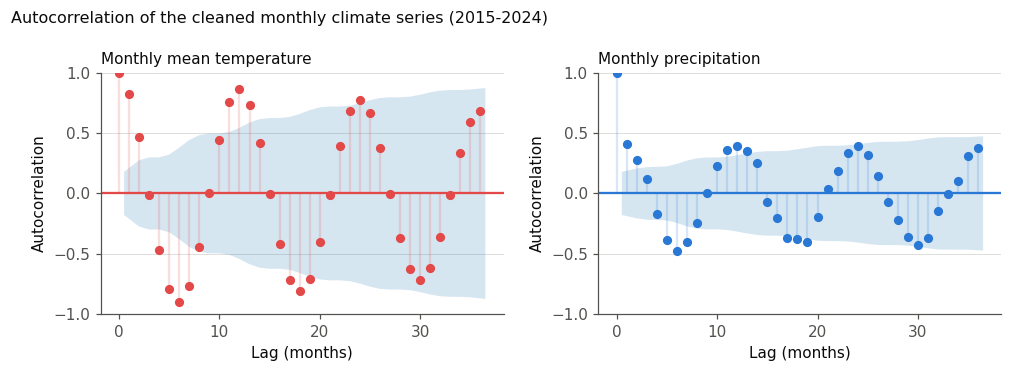

In [29]:
# Autocorrelation of the cleaned monthly climate series. Population is deliberately
# absent: the annual series has 15 points, far too few for a meaningful ACF, and the
# monthly-interpolated population ACF shown in the previous version of the manuscript
# described the spline, not the population.
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.4))
for ax, (col, title, c) in zip(axes, [("temp_avg_c", "Monthly mean temperature", PAL["red"]),
                                      ("precip_mm", "Monthly precipitation", PAL["blue"])]):
    plot_acf(clim[col].values, lags=36, ax=ax, color=c, vlines_kwargs={"colors": c},
             title="")
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_xlabel("Lag (months)"); ax.set_ylabel("Autocorrelation")
    ax.grid(axis="y"); ax.set_axisbelow(True)
    for coll in ax.collections:
        coll.set_alpha(0.18)
fig.suptitle("Autocorrelation of the cleaned monthly climate series (2015-2024)",
             x=0.005, ha="left", fontsize=10.5)
fig.tight_layout()
fig.savefig(FIG / "fig7_climate_acf.png")
plt.show()

## 6. Reproducibility export

`run_manifest.json` records the seed, the interpreter and package versions, and a
SHA-256 checksum of each input workbook, so an archived copy of `outputs/` can be
tied to the exact inputs that produced it.

In [30]:
import importlib

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 16), b""):
            h.update(chunk)
    return h.hexdigest()

PACKAGES = ["numpy", "pandas", "scipy", "scikit-learn", "statsmodels",
            "matplotlib", "openpyxl"]
versions = {}
IMPORT_NAME = {"scikit-learn": "sklearn"}
for p in PACKAGES:
    try:
        versions[p] = importlib.import_module(IMPORT_NAME.get(p, p)).__version__
    except Exception:
        versions[p] = "unknown"

with open(NB_DIR / "requirements.txt", "w") as fh:
    for p, v in versions.items():
        fh.write(f"{p}=={v}\n")

manifest = {
    "notebook": "Soran_Population_Forecast.ipynb",
    "seed": SEED,
    "python": sys.version.split()[0],
    "packages": versions,
    "inputs": {p.name: {"sha256": sha256(p), "bytes": p.stat().st_size}
               for p in [POP_XLSX, CLIMATE_XLSX, LEGACY_XLSX]},
    "population_series": {"years": [int(YEARS[0]), int(YEARS[-1])],
                          "n_annual_observations": len(YEARS),
                          "census_rebasing_year": CENSUS_YEAR},
    "forecast_years": FORECAST_YEARS,
    "rolling_origin": {"min_train_years": MIN_TRAIN, "n_folds": int(len(rolling))},
}
with open(OUT / "run_manifest.json", "w") as fh:
    json.dump(manifest, fh, indent=2)

print("outputs written:")
for root, _, files in os.walk(OUT):
    for fn in sorted(files):
        print("  ", Path(root, fn).relative_to(NB_DIR))

outputs written:
   outputs/run_manifest.json
   outputs/tables/adf_stationarity_tests.csv
   outputs/tables/arima_order_selection.csv
   outputs/tables/benchmark_comparison.csv
   outputs/tables/climate_annual_clean.csv
   outputs/tables/climate_monthly_clean.csv
   outputs/tables/data_quality_flags.csv
   outputs/tables/decoupling_annual_lagged_correlation.csv
   outputs/tables/diebold_mariano_results.csv
   outputs/tables/final_forecast_2025_2030.csv
   outputs/tables/fold_level_absolute_errors.csv
   outputs/tables/forecast_specification_comparison.csv
   outputs/tables/growth_rate_break_diagnostics.csv
   outputs/tables/in_sample_fit_statistics.csv
   outputs/tables/population_annual_clean.csv
   outputs/tables/population_series_comparison.csv
   outputs/tables/rolling_origin_error_summary.csv
   outputs/tables/rolling_origin_forecast_errors.csv
   outputs/figures/fig1_population_and_growth.png
   outputs/figures/fig2_correlation_heatmap.png
   outputs/figures/fig3_rolling_origin_

## 7. What this means for the manuscript

**Data and Methods**

1. Replace the population data description with the official series: 15 annual
   observations, 2010–2024, Statistics Directorate of the Soran Independent
   Administration. State that 2010–2023 are inter-censal estimates produced by
   applying an estimated growth rate to the 2009–2010 enumeration, and that 2024
   comes from the 2024 census round (district total 179,596).
2. State that no interpolated monthly population series is used anywhere in the
   analysis. The cubic spline appears only inside the MLP folds, fitted on training
   years only.
3. Report the climate QA protocol and cite `outputs/tables/data_quality_flags.csv`
   for the affected cells (the 2016 maximum-temperature column, the 2020 June–September
   block, the 2023 evaporation-pan outage).
4. Rename SARIMAX to ARIMAX throughout; `seasonal_order` is `(0,0,0,0)` and the order
   is selected by AIC grid search, not asserted.

**Results**

5. Replace Table 4 with `rolling_origin_error_summary.csv`, reported in two panels
   (all folds / excluding the rebasing year), and state in the text that the sub-0.1%
   errors on the inter-censal segment measure the smoothness of the administrative
   estimates rather than forecasting skill.
6. Report every Diebold–Mariano statistic with its `n_independent_forecasts`.
   Remove any "p < 0.0001" claim.
7. Replace the "Consensus Range" with `final_forecast_2025_2030.csv`: a point
   projection plus a named scenario range, with the assumed growth rate for each year
   given explicitly.
8. Move the polynomial and log-linear full-sample results into a short subsection on
   specification failure — they project a 2025 population below the observed 2024
   value, which is the clearest available demonstration that a smooth trend cannot be
   fitted across the census rebasing.

**Discussion and limitations**

9. Reword the decoupling claim: the available series *cannot resolve* a
   climate–demography association at annual resolution, because the pre-2024
   population values are administratively smoothed. Do not state that population and
   climate are decoupled in Soran.
10. State the 2024 comparability break as a limitation, and note that a second
    post-census observation is needed before the post-2024 growth rate can be
    estimated from data rather than assumed.
11. Keep the causal socio-economic and water-resource language out of Results, and
    label it as hypothesis in the Discussion unless independent series are added.

**Data availability**

12. Archive this notebook together with `data/` and `outputs/` on GitHub with a
    Zenodo DOI and cite that DOI, replacing "All data are contained within the article."